# 01 · Explorando o FAQ do Riftbound

**Objetivo:** entender os dados **antes** de limpar qualquer coisa. Este notebook responde três perguntas:

1. Quantos arquivos são e como estão organizados?
2. Como é um arquivo por dentro?
3. O que precisa ser limpo e o que vale guardar como **metadado** (informação sobre o texto, como título, carta e regras citadas)?

No fim, a seção 14 resume tudo e vira a especificação da etapa 2 (limpeza e divisão em trechos).

> **Fonte:** [Riftbound FAQ](https://www.riftboundfaq.com), de Christian "Near" Ivicevic. O conteúdo tem licença [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).
> **Antes de rodar:** `python -m juiz.baixar_faq`, que baixa os dados para `data/raw/`.

In [1]:
import json
import re
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml

# O notebook roda de dentro de notebooks/, então colocamos a raiz do projeto no
# caminho de importação do Python para conseguir fazer "from juiz import config".
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from juiz import config

pd.set_option("display.max_colwidth", 90)
assert config.FAQ_CONTENT_DIR.exists(), "Rode antes: python -m juiz.baixar_faq"

## 1. De onde vieram os dados (procedência)

O script de download grava de qual **commit** (versão) do repositório os dados vieram.
Mais pra frente, isso deixa o app dizer "respostas baseadas no FAQ de 20/09/2026".

In [2]:
snapshot = json.loads(config.FAQ_SNAPSHOT.read_text(encoding="utf-8"))
snapshot

{'repositorio': 'https://github.com/ChristianIvicevic/riftboundfaq.git',
 'commit': 'ac76c13fba1d06640ece5fde6b3062213a62c8c6',
 'data_commit': '2026-09-20T22:00:07+10:00',
 'mensagem_commit': 'Explain Elder Dragon combat damage assignment',
 'baixado_em': '2026-09-23T21:43:09+00:00',
 'total_mdx': 63,
 'mdx_por_categoria': {'about': 1,
  'cards': 49,
  'general-rules': 7,
  'mechanics': 6},
 'crd_versao_atual': '1.4'}

## 2. Como os arquivos estão organizados

O site é feito com o [Fumadocs](https://fumadocs.dev) (Next.js). Duas convenções importam aqui:

- Uma pasta entre parênteses, como `(rulings)`, é um **grupo de rotas**: organiza os arquivos, mas **não aparece na URL**.
  Por exemplo, `content/(rulings)/cards/flash.mdx` vira `riftboundfaq.com/cards/flash`.
- Os `meta.json` controlam o menu lateral do site: título da categoria, ícone e ordem das páginas.

In [3]:
arquivos = sorted(p for p in config.FAQ_CONTENT_DIR.rglob("*") if p.is_file())
print(f"{len(arquivos)} arquivos em content/\n")
print(pd.Series([p.suffix for p in arquivos]).value_counts().to_string())

68 arquivos em content/

.mdx     63
.json     5


In [4]:
for meta in sorted(config.FAQ_CONTENT_DIR.rglob("meta.json")):
    print(f"{meta.relative_to(config.FAQ_CONTENT_DIR).as_posix():<35}", json.loads(meta.read_text(encoding="utf-8")))

(rulings)/cards/meta.json           {'title': 'Cards', 'icon': 'GalleryHorizontalEnd', 'defaultOpen': True, 'collapsible': True, 'pages': ['...']}
(rulings)/general-rules/meta.json   {'title': 'General Rules', 'icon': 'BookOpenText', 'defaultOpen': False, 'collapsible': True, 'pages': ['...']}
(rulings)/mechanics/meta.json       {'title': 'Mechanics', 'icon': 'Tags', 'defaultOpen': False, 'collapsible': True, 'pages': ['...']}
(rulings)/meta.json                 {'title': 'Rulings', 'description': 'Answers to common rules questions', 'root': True, 'icon': 'MessageCircleQuestionMark', 'pages': ['---Introduction---', 'index', '---Browse Rulings---', 'general-rules', 'mechanics', 'cards']}
meta.json                           {'pages': ['(rulings)', 'reference']}


**O que isso mostra:**
- `"pages": ["..."]` quer dizer "todas as páginas da pasta, em ordem alfabética". Os `meta.json` não trazem informação sobre o conteúdo; só vale aproveitar o **nome bonito da categoria** ("General Rules", "Mechanics", "Cards") como metadado.
- O `content/meta.json` lista uma seção `reference` que **não existe como arquivo**. Ela é gerada por script a partir dos PDFs do CRD (é a versão HTML do CRD com âncora por regra). Isso é relevante pra etapa 3.

## 3. Anatomia de um arquivo MDX

**MDX = Markdown + componentes** (no estilo de tags HTML, como `<Rule number="355.9.a" />`).
No site, cada componente vira algo visual, como um link pra regra, um card com a imagem da carta ou uma caixa de exemplo.
Pro nosso chatbot, esses componentes são **ruído no texto**, mas carregam **informação útil**, como qual regra foi citada e qual carta foi mencionada.

Vamos olhar um arquivo pequeno inteiro:

In [5]:
print((config.FAQ_CONTENT_DIR / "(rulings)" / "cards" / "flash.mdx").read_text(encoding="utf-8"))

---
title: "Flash"
createdAt: "2026-05-07"
reviewedCoreRulesVersion: "1.4"
authors:
- name: "Christian “Near” Ivicevic"
  url: "https://x.com/civicevic"
---

## Can Flash target a unit that is already in base? [#target-in-base]

Yes, Flash can target a friendly unit that is already in base.<Rule number="355.9.a" /><Rule number="355.9.b" /><Rule number="355.10" />
Flash specifies base as the destination instead of asking you to choose one, so the different-location restriction for player-chosen destinations does not make a unit already in base an illegal target.<Rule number="002" /><Rule number="355.4" /><Rule number="355.4.a" />

When Flash <Term item="resolution">resolves</Term>, the unit cannot move because it would not change from one board space to another.<Rule number="446.1" />



Um arquivo tem três partes:

1. **Frontmatter**: o bloco YAML entre `---`, com título, data de criação, versão do CRD usada na revisão e autores.
2. **Títulos de pergunta**: `## Pergunta? [#ancora]`. A âncora é o que vem depois do `#` na URL (`.../flash#target-in-base`), então dá pra **linkar direto na resposta**.
3. **Texto com componentes**: `<Rule number="..." />` marca a regra do CRD que justifica cada frase. É ouro pra citar fontes.

## 4. Carregando tudo numa tabela

Agora lemos os 63 arquivos e montamos um DataFrame com uma linha por arquivo.
A contagem de palavras aqui é **aproximada**: tiramos as tags `<...>` e contamos o que sobra.

In [6]:
RE_FRONTMATTER = re.compile(r"^---\n(.*?)\n---\n", re.DOTALL)
RE_TAG = re.compile(r"<[^>]+>")  # qualquer tag <...>


def ler_mdx(caminho: Path) -> tuple[dict, str]:
    # Separa o frontmatter (YAML) do corpo (Markdown + componentes).
    texto = caminho.read_text(encoding="utf-8")
    m = RE_FRONTMATTER.match(texto)
    return yaml.safe_load(m.group(1)), texto[m.end():]


def url_da_pagina(caminho: Path) -> str:
    rel = caminho.relative_to(config.FAQ_CONTENT_DIR).with_suffix("")
    partes = [p for p in rel.parts if not p.startswith("(")]  # grupos "(...)" não entram na URL
    if partes and partes[-1] == "index":
        partes = partes[:-1]
    return config.FAQ_SITE_URL + "/" + "/".join(partes)


def contar_palavras(texto: str) -> int:
    return len(RE_TAG.sub(" ", texto).split())


linhas = []
for caminho in sorted(config.FAQ_CONTENT_DIR.rglob("*.mdx")):
    fm, corpo = ler_mdx(caminho)
    linhas.append({
        "arquivo": caminho.relative_to(config.FAQ_CONTENT_DIR).as_posix(),
        "categoria": "about" if caminho.parent.name.startswith("(") else caminho.parent.name,
        "titulo": fm.get("title"),
        "criado_em": fm.get("createdAt"),
        "crd_revisado": fm.get("reviewedCoreRulesVersion"),
        "palavras": contar_palavras(corpo),
        "n_perguntas": len(re.findall(r"^## ", corpo, re.M)),
        "n_subperguntas": len(re.findall(r"^### ", corpo, re.M)),
        "url": url_da_pagina(caminho),
        "corpo": corpo,
        "frontmatter": fm,
    })

docs = pd.DataFrame(linhas)
docs.drop(columns=["corpo", "frontmatter"]).head()

,arquivo,categoria,titulo,criado_em,crd_revisado,palavras,n_perguntas,n_subperguntas,url
0,(rulings)/cards/abandoned-hall.mdx,cards,Abandoned Hall,2026-04-19,1.4,290,3,0,https://www.riftboundfaq.com/cards/abandoned-hall
1,(rulings)/cards/akshan-mischievous.mdx,cards,"Akshan, Mischievous",2026-04-14,1.4,261,2,0,https://www.riftboundfaq.com/cards/akshan-mischievous
2,(rulings)/cards/alpha-strike.mdx,cards,Alpha Strike,2026-04-30,1.4,686,5,0,https://www.riftboundfaq.com/cards/alpha-strike
3,(rulings)/cards/aphelios-exalted.mdx,cards,"Aphelios, Exalted",2026-07-23,1.4,213,1,0,https://www.riftboundfaq.com/cards/aphelios-exalted
4,(rulings)/cards/applied-researchers.mdx,cards,Applied Researchers,2026-08-08,1.4,263,2,1,https://www.riftboundfaq.com/cards/applied-researchers


## 5. Quantos arquivos e de que tamanho

In [7]:
resumo = docs.groupby("categoria").agg(
    arquivos=("arquivo", "count"),
    perguntas=("n_perguntas", "sum"),
    subperguntas=("n_subperguntas", "sum"),
    palavras_total=("palavras", "sum"),
    palavras_media=("palavras", "mean"),
    palavras_min=("palavras", "min"),
    palavras_max=("palavras", "max"),
)
resumo.loc["TOTAL"] = [
    len(docs), docs.n_perguntas.sum(), docs.n_subperguntas.sum(), docs.palavras.sum(),
    docs.palavras.mean(), docs.palavras.min(), docs.palavras.max(),
]
resumo.round(0).astype(int)

,arquivos,perguntas,subperguntas,palavras_total,palavras_media,palavras_min,palavras_max
categoria,,,,,,,
about,1,4,0,308,308,308,308
cards,49,117,11,14794,302,54,1454
general-rules,7,28,2,3819,546,267,887
mechanics,6,21,0,2069,345,259,441
TOTAL,63,170,13,20990,333,54,1454


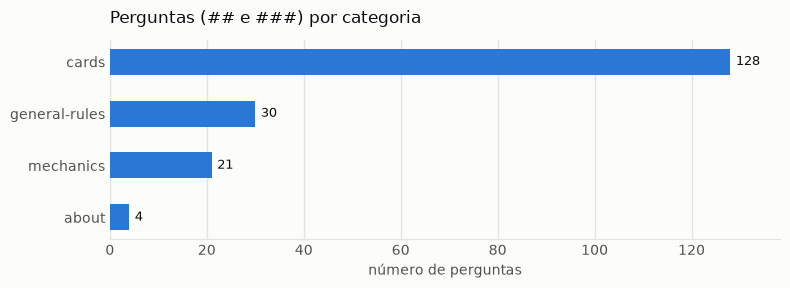

In [8]:
# Estilo dos gráficos: uma cor só (é uma série só), grade discreta, valor na ponta da barra.
COR_SERIE, COR_TEXTO, COR_TEXTO_2, COR_GRADE, COR_FUNDO = "#2a78d6", "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"


def barras_horizontais(serie: pd.Series, titulo: str, rotulo_x: str) -> None:
    serie = serie.sort_values()
    fig, ax = plt.subplots(figsize=(8, 0.42 * len(serie) + 1.3), facecolor=COR_FUNDO)
    ax.set_facecolor(COR_FUNDO)
    barras = ax.barh(serie.index, serie.values, height=0.5, color=COR_SERIE)
    ax.bar_label(barras, padding=4, color=COR_TEXTO, fontsize=9)
    ax.set_title(titulo, loc="left", color=COR_TEXTO, fontsize=12, pad=12)
    ax.set_xlabel(rotulo_x, color=COR_TEXTO_2)
    ax.tick_params(colors=COR_TEXTO_2, length=0)
    ax.xaxis.grid(True, color=COR_GRADE, linewidth=1)
    ax.set_axisbelow(True)
    for lado in ["top", "right", "left"]:
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(COR_GRADE)
    ax.margins(x=0.08)
    plt.tight_layout()
    plt.show()


perguntas_por_categoria = (docs.n_perguntas + docs.n_subperguntas).groupby(docs.categoria).sum()
barras_horizontais(perguntas_por_categoria, "Perguntas (## e ###) por categoria", "número de perguntas")

**Leitura:** o FAQ é **pequeno** (cerca de 21 mil palavras). Então por que não mandar tudo pro LLM de uma vez, em vez de fazer RAG?
- O **CRD** (etapa 3) é bem maior e também entra na base.
- Mandar só os trechos relevantes deixa cada pergunta **mais barata e mais rápida**, e ajuda a **citar a fonte certa**.
- Menos texto irrelevante no prompt também reduz a chance do modelo misturar regras.

## 6. Frontmatter: que campos existem em cada arquivo?

In [9]:
presenca = pd.DataFrame([{chave: True for chave in fm} for fm in docs.frontmatter]).notna()
presenca.sum().to_frame("arquivos com o campo")

,arquivos com o campo
title,63
createdAt,63
reviewedCoreRulesVersion,62
authors,62
description,1
icon,1


In [10]:
print("Arquivos sem 'reviewedCoreRulesVersion':", docs.loc[docs.crd_revisado.isna(), "arquivo"].tolist())
print("Autores:", Counter(a["name"] for fm in docs.frontmatter for a in fm.get("authors", [])))

Arquivos sem 'reviewedCoreRulesVersion': ['(rulings)/index.mdx']
Autores: Counter({'Christian “Near” Ivicevic': 62})


Só o `index.mdx` ("About this site") não tem versão do CRD nem autor, o que faz sentido: ele fala do site, não de regras.
Esse arquivo explica o FAQ, mas **não responde dúvidas de regra**. Na etapa 2 a gente decide se ele entra no índice (provavelmente não).

## 7. As perguntas (seções): a unidade natural dos trechos

No RAG, a busca não devolve o documento inteiro, e sim **trechos** (chunks). O ideal é que cada trecho responda **uma coisa só**.
Aqui o autor já dividiu o conteúdo por pergunta, então cada `##`/`###` é um candidato natural a trecho, com URL própria.

In [11]:
RE_TITULO = re.compile(r"^(#{2,3}) (.+?)(?: \[#([\w-]+)\])?[ \t]*$", re.M)

secoes = []
for d in docs.itertuples():
    titulos = list(RE_TITULO.finditer(d.corpo))
    for i, t in enumerate(titulos):
        fim = titulos[i + 1].start() if i + 1 < len(titulos) else len(d.corpo)
        texto = d.corpo[t.end():fim]
        secoes.append({
            "arquivo": d.arquivo,
            "categoria": d.categoria,
            "nivel": len(t.group(1)),
            "pergunta": t.group(2),
            "ancora": t.group(3),
            "url": f"{d.url}#{t.group(3)}" if t.group(3) else d.url,
            "palavras": contar_palavras(texto),
            "regras_citadas": len(re.findall(r"<Rule number=", texto)),
        })
secoes = pd.DataFrame(secoes)

print(f"{len(secoes)} seções ({(secoes.nivel == 2).sum()} de nível ## e {(secoes.nivel == 3).sum()} de nível ###)")
print("Seções sem âncora:", secoes.ancora.isna().sum())
print("Títulos terminados em '?':", f"{secoes.pergunta.str.endswith('?').mean():.0%}")
secoes.head(8)

183 seções (170 de nível ## e 13 de nível ###)
Seções sem âncora: 0
Títulos terminados em '?': 91%


,arquivo,categoria,nivel,pergunta,ancora,url,palavras,regras_citadas
0,(rulings)/cards/abandoned-hall.mdx,cards,2,Does Abandoned Hall's ability trigger if the spell is countered?,countered-spell,https://www.riftboundfaq.com/cards/abandoned-hall#countered-spell,44,2
1,(rulings)/cards/abandoned-hall.mdx,cards,2,Can a unit moved into or away from Abandoned Hall by a spell be targeted?,movement-eligibility,https://www.riftboundfaq.com/cards/abandoned-hall#movement-eligibility,109,7
2,(rulings)/cards/abandoned-hall.mdx,cards,2,Can Abandoned Hall's triggered ability choose a unit that a spell plays there?,replay,https://www.riftboundfaq.com/cards/abandoned-hall#replay,93,12
3,(rulings)/cards/akshan-mischievous.mdx,cards,2,"If my Dazzling Aurora plays Akshan, Mischievous at the end of my turn, will the Dazzli...",aurora-timing,https://www.riftboundfaq.com/cards/akshan-mischievous#aurora-timing,124,7
4,(rulings)/cards/akshan-mischievous.mdx,cards,2,"If my opponent and I each use Akshan, Mischievous to take the same gear, who controls ...",dual-akshan-control,https://www.riftboundfaq.com/cards/akshan-mischievous#dual-akshan-control,87,8
5,(rulings)/cards/alpha-strike.mdx,cards,2,How are targets chosen when playing Alpha Strike?,targeting,https://www.riftboundfaq.com/cards/alpha-strike#targeting,96,11
6,(rulings)/cards/alpha-strike.mdx,cards,2,When and how is Alpha Strike's damage distributed?,split-distribution,https://www.riftboundfaq.com/cards/alpha-strike#split-distribution,136,10
7,(rulings)/cards/alpha-strike.mdx,cards,2,What if the friendly unit's might is reduced?,might-reduction,https://www.riftboundfaq.com/cards/alpha-strike#might-reduction,157,10


In [12]:
# Tamanho das seções em palavras: define se uma seção cabe inteira num trecho.
secoes.palavras.describe(percentiles=[0.5, 0.9, 0.95]).round(0).to_frame("palavras por seção").T

,count,mean,std,min,50%,90%,95%,max
palavras por seção,183.0,100.0,54.0,22.0,88.0,175.0,192.0,349.0


In [13]:
secoes.nlargest(5, "palavras")[["arquivo", "pergunta", "palavras"]]

,arquivo,pergunta,palavras
85,(rulings)/cards/promising-future.mdx,Steps,349
154,(rulings)/general-rules/targeting.mdx,What makes something a target?,333
43,(rulings)/cards/elder-dragon.mdx,How does Elder Dragon affect combat damage assignment?,268
44,(rulings)/cards/elder-dragon.mdx,"Does damage from earlier in the turn become lethal when Elder Dragon enters, and can I...",247
56,(rulings)/cards/gangplank-naval.mdx,"What happens when Switcheroo would reduce an Empowered Gangplank, Naval's might?",239


In [14]:
vazias = secoes[secoes.palavras == 0]
print(f"Seções com 0 palavras (o texto está todo nas subseções ###): {len(vazias)}")
vazias[["arquivo", "pergunta"]].head()

Seções com 0 palavras (o texto está todo nas subseções ###): 0


,arquivo,pergunta


**Leitura:**
- Todas as seções têm âncora, então **toda resposta pode ter um link direto** pra pergunta certa no site.
- Nem todo título é uma pergunta: alguns são afirmações, como "Units can join combat late and still trigger". Não tem problema, porque o título entra no trecho como contexto.
- **Tamanho:** muitos modelos de embeddings leem no máximo uns ~512 tokens (em inglês, 1 palavra dá mais ou menos 1,3 token). A maior seção tem 349 palavras (uns 450 tokens) e a mediana é de 88, então **todas cabem inteiras num trecho** e não precisa dividir nenhuma.
- **Decisão pra etapa 2:** uma `###` fica abaixo de uma `##`, e sozinha ela pode não dizer nada. Por exemplo, `### Steps` fica embaixo de "How does Promising Future resolve?". Então o trecho de cada `###` precisa **carregar o título da `##` mãe** pra não perder o contexto.
  *Decidido na etapa 2:* 11 das 13 `###` são continuação da resposta ("Steps", "Cost Sequence"…), então elas **entram no mesmo trecho da `##`**. Juntando, o maior trecho fica com uns 400 palavras.

## 8. Componentes MDX: o que precisa limpar

Aqui contamos cada componente e classificamos **o que ele é** e **o que fazer com ele** na etapa 2.
A lista de palavras-chave vem do próprio repositório do FAQ (`src/lib/mdx-vocabulary.ts`).

In [15]:
RE_COMPONENTE = re.compile(r"<([A-Z]\w*)\b([^>]*?)/?>")

# Palavras-chave do jogo que o site mostra como "etiqueta" (fonte: mdx-vocabulary.ts do FAQ).
PALAVRAS_CHAVE = {
    "Accelerate", "Action", "Add", "Ambush", "Assault", "Burn", "Deathknell", "Deflect", "Equip",
    "Empower", "Empowered", "Flow", "Hidden", "Legion", "Mighty", "Predict", "QuickDraw", "Reaction",
    "Repeat", "Shield", "Stun", "Temporary", "Weaponmaster",
}
RUNAS = {"Fury", "Calm", "Mind", "Body", "Chaos", "Order"}

TIPOS = {
    "Rule": ("Regra do CRD citada", "tirar do texto e guardar em metadado `regras` (lista)"),
    "Term": ("Termo do glossário (Term)", "manter só o texto de dentro: <Term ...>resolves</Term> -> resolves"),
    "Card": ("Nome de carta", "trocar pelo nome e guardar em metadado `cartas`"),
    "Callout": ("Caixa: exemplo, aviso ou errata", "manter o conteúdo com o título como prefixo; marcar avisos"),
    "Steps": ("Lista de passos", "virar lista numerada"),
    "Step": ("Lista de passos", "virar lista numerada"),
    "Energy": ("Custo (energia/poder)", "<Energy value={2} /> -> [2]"),
    "Universal": ("Custo (energia/poder)", "-> [Power] (igual à busca do site)"),
}


def classificar(nome: str) -> tuple[str, str]:
    if nome in TIPOS:
        return TIPOS[nome]
    if nome in PALAVRAS_CHAVE:
        return ("Palavra-chave do jogo", "<Shield /> -> [Shield] (QuickDraw -> [Quick-Draw])")
    if nome in RUNAS:
        return ("Runa / domínio", "<Fury /> -> [Fury]")
    return ("DESCONHECIDO", "investigar")


contagem = Counter(m.group(1) for corpo in docs.corpo for m in RE_COMPONENTE.finditer(corpo))
componentes = pd.DataFrame({"ocorrencias": pd.Series(contagem)}).sort_values("ocorrencias", ascending=False)
componentes["arquivos"] = [docs.corpo.str.contains(rf"<{nome}\b").sum() for nome in componentes.index]
componentes[["tipo", "o que fazer na etapa 2"]] = [classificar(nome) for nome in componentes.index]
componentes

,ocorrencias,arquivos,tipo,o que fazer na etapa 2
Rule,1134,62,Regra do CRD citada,tirar do texto e guardar em metadado `regras` (lista)
Term,301,53,Termo do glossário (Term),manter só o texto de dentro: <Term ...>resolves</Term> -> resolves
Card,106,35,Nome de carta,trocar pelo nome e guardar em metadado `cartas`
Step,73,14,Lista de passos,virar lista numerada
Deathknell,39,6,Palavra-chave do jogo,<Shield /> -> [Shield] (QuickDraw -> [Quick-Draw])
Callout,35,23,"Caixa: exemplo, aviso ou errata",manter o conteúdo com o título como prefixo; marcar avisos
Energy,25,9,Custo (energia/poder),<Energy value={2} /> -> [2]
Empowered,22,5,Palavra-chave do jogo,<Shield /> -> [Shield] (QuickDraw -> [Quick-Draw])
Repeat,18,6,Palavra-chave do jogo,<Shield /> -> [Shield] (QuickDraw -> [Quick-Draw])
Steps,17,14,Lista de passos,virar lista numerada


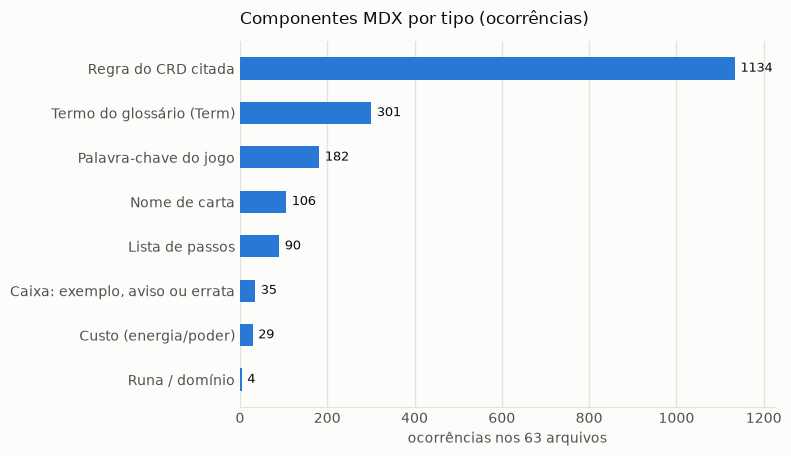

In [16]:
por_tipo = componentes.groupby("tipo").ocorrencias.sum()
barras_horizontais(por_tipo, "Componentes MDX por tipo (ocorrências)", "ocorrências nos 63 arquivos")

Um exemplo real de cada tipo, com um pouco do texto em volta:

In [17]:
todo_corpo = "\n".join(docs.corpo)
for nome in ["Rule", "Term", "Card", "Callout", "Steps", "Energy", "Universal", "Deathknell", "Fury"]:
    m = re.search(rf"<{nome}\b", todo_corpo)
    trecho = todo_corpo[max(0, m.start() - 60): m.start() + 110].replace("\n", " ⏎ ")
    print(f"[{nome}]  ...{trecho}...\n")

[Rule]  ...hat spell finishes <Term item="resolution">resolving</Term>.<Rule number="419.4.a" /> ⏎ A countered spell does not resolve and is not considered played for triggered abilit...

[Term]  ...spell" condition is fulfilled only when that spell finishes <Term item="resolution">resolving</Term>.<Rule number="419.4.a" /> ⏎ A countered spell does not resolve and is n...

[Card]  ...t turn? [#aurora-timing] ⏎  ⏎ No. ⏎ You gain control of the enemy <Card name="Dazzling Aurora" /> after its end-of-turn trigger condition has already been checked. ⏎  ⏎ "At the end...

[Callout]  ..." /><Rule number="355.14.h" /><Rule number="355.14.h.1" /> ⏎  ⏎ <Callout type="idea" title="Example"> ⏎ 	You chose a friendly <Card name="Pakaa Cub" /> with 3 might, then chose...

[Steps]  ....9.b" /><Rule number="355.10" /><Rule number="355.14.a" /> ⏎  ⏎ <Steps> ⏎ <Step> ⏎ Choose one friendly unit. ⏎ </Step> ⏎ <Step> ⏎ Check that unit's might, then choose any legal number ...

[Energy]  ...<Empowered />, you 

In [18]:
# Outros elementos de Markdown que aparecem (e que o LLM entende bem, então dá pra manter).
outros = {
    "negrito (**...**)": docs.corpo.str.contains(r"\*\*").sum(),
    "listas (- item)": docs.corpo.str.contains(r"^\s*[-*] ", regex=True, flags=re.M).sum(),
    "links [texto](url)": docs.corpo.str.contains(r"\]\(").sum(),
    "tabelas": docs.corpo.str.contains(r"^\|", regex=True, flags=re.M).sum(),
    "import/export (código)": docs.corpo.str.contains(r"^(?:import|export) ", regex=True, flags=re.M).sum(),
}
pd.Series(outros).to_frame("arquivos")

,arquivos
negrito (**...**),15
listas (- item),12
links [texto](url),8
tabelas,0
import/export (código),0


**Leitura:** não apareceu nenhum componente `DESCONHECIDO`, então a tabela acima cobre **tudo** o que a limpeza precisa tratar.
Não tem `import`/`export` nem tabelas, o que simplifica bastante. Negrito, listas e links podem ficar, porque o LLM lê Markdown sem problema.

## 9. Regras do CRD citadas pelo FAQ

Esse é o elo entre as duas fontes. Cada `<Rule number="..."/>` diz qual regra oficial sustenta a frase.
Na etapa 5 dá pra fazer o seguinte: quando a busca achar um trecho do FAQ, **puxar também o texto oficial das regras que ele cita**.
Assim o LLM vê a explicação do FAQ e a regra oficial lado a lado, e a regra oficial manda.

In [19]:
regras = pd.Series([n for corpo in docs.corpo for n in re.findall(r'<Rule number="([^"]+)"', corpo)])
print(f"{len(regras)} citações de {regras.nunique()} regras diferentes")
print("Formato fora do padrão (ex.: 355.9.a):", regras[~regras.str.match(r"^\d{3}(\.[0-9a-z]+)*$")].tolist())
print(f"Seções sem nenhuma regra citada: {(secoes.regras_citadas == 0).sum()} de {len(secoes)}")
regras.value_counts().head(10).to_frame("citações")

1134 citações de 408 regras diferentes
Formato fora do padrão (ex.: 355.9.a): []
Seções sem nenhuma regra citada: 8 de 183


,citações
354.2,18
337.2,16
359.2.c,14
383.4.a.2,14
406.4,14
383.3,13
383.2.c,13
337.4,13
354.3,12
355.5,12


In [20]:
# Agrupando pela "centena" da regra (ex.: 355.9.a -> 3xx), pra ver quais partes do CRD o FAQ mais usa.
# Os nomes dessas partes a gente descobre na etapa 3, quando ler o CRD.
(regras.str[0] + "xx").value_counts().sort_index().to_frame("citações")

,citações
0xx,5
1xx,48
2xx,7
3xx,711
4xx,246
7xx,24
8xx,93


## 10. Contra qual versão do CRD cada página foi revisada?

O CRD muda de versão (v1.0 até v1.4), e o **número das regras pode mudar** entre versões.
Se uma página foi revisada contra uma versão antiga, as citações dela podem estar desatualizadas.

In [21]:
atual = snapshot["crd_versao_atual"]
print("Versão atual do CRD:", atual)
print(docs.crd_revisado.value_counts(dropna=False).to_string())
desatualizadas = docs[docs.crd_revisado.notna() & (docs.crd_revisado != atual)]
desatualizadas[["arquivo", "crd_revisado"]]

Versão atual do CRD: 1.4
crd_revisado
1.4    62
NaN     1


,arquivo,crd_revisado


## 11. Callouts: exemplos, avisos e erratas

In [22]:
RE_CALLOUT = re.compile(r'<Callout type="(\w+)" title="([^"]*)">(.*?)</Callout>', re.DOTALL)
callouts = pd.DataFrame(
    [(d.arquivo, *m.groups()) for d in docs.itertuples() for m in RE_CALLOUT.finditer(d.corpo)],
    columns=["arquivo", "tipo", "titulo", "conteudo"],
)
callouts.groupby(["tipo", "titulo"]).size().sort_values(ascending=False).to_frame("quantidade")

quantidade
tipo titulo                                      
idea Example                                   24
warn Rules citation needed                      7
     Errata                                     2
idea Elder Dragon vs. Imperial Decree           1
info Earlier Svellsongur ruling                 1

In [23]:
for c in callouts[callouts.titulo == "Rules citation needed"].itertuples():
    print(f"--- {c.arquivo}")
    print(RE_TAG.sub("", c.conteudo).strip(), "\n")

--- (rulings)/cards/gangplank-naval.mdx
Core Rules 1.4 does not yet make this no-recalculation result explicit, and its swap rules need clarification. 

--- (rulings)/cards/hidden-blade.mdx
Core Rules 1.4 still calls instructions prevented by other circumstances "ignored."
	The linked Vendetta FAQ narrows that term to mistargeting and expressly takes precedence on this point until a later Core Rules Document says otherwise. 

--- (rulings)/cards/nocturne-horrifying.mdx
"Look" does not have a standalone numbered action definition in Core Rules 1.4.
	Unlike reveal, the rules do not expressly state that a player looks at cards only when instructed.
	This ruling relies on treating "look at" as an instructed event; an official definition is still needed. 

--- (rulings)/cards/rebuttal.mdx
Core Rules 1.4 does not independently supply the distinction between remaking at least one choice and leaving every choice unchanged.
	The cited FAQ notes that this Core Rules section will be revised in a 

**Achado importante:**
- As caixas **"Rules citation needed"** marcam respostas que o CRD ainda **não sustenta por completo**. Vale guardar isso num metadado (`citacao_pendente = True`), pra que o chatbot avise que a resposta tem menos certeza.
- Em 3 páginas (`hidden-blade`, `movement`, `targeting`), o FAQ diz que o **FAQ oficial da Riot** (Vendetta Rules FAQ and Clarifications) **tem precedência sobre o CRD** naquele ponto, até sair um CRD novo. Em `rebuttal`, a resposta segue uma decisão do FAQ oficial.
  Então a hierarquia completa fica **CRD > FAQ não oficial, exceto quando um FAQ oficial da Riot esclarece o ponto explicitamente**. Isso precisa entrar nas regras do prompt (etapa 5).

## 12. Links externos: que outras fontes o FAQ cita?

In [24]:
links = pd.Series([u for corpo in docs.corpo for u in re.findall(r"\]\((https?://[^)]+)\)", corpo)])
links.value_counts().to_frame("citações")

,citações
https://playriftbound.com/en-us/news/rules-and-releases/vendetta-rules-faq-and-clarifications,8
https://playriftbound.com/en-us/news/rules-and-releases/riftbound-spiritforged-faq/,1
https://x.com/civicevic,1
https://github.com/ChristianIvicevic/riftboundfaq/issues,1
https://www.riotgames.com/en/legal,1


O FAQ cita os **FAQs oficiais da Riot** de cada coleção (Spiritforged, Vendetta). Eles podem ser uma **terceira fonte** interessante no futuro, já que são oficiais e às vezes mais recentes que o CRD.

## 13. Arquivos extras: catálogo de cartas e erratas

Esses dois arquivos vieram no download. A decisão de usar ou não fica pra etapa 5; aqui é só uma olhada no formato.

In [25]:
cartas = pd.read_json(config.FAQ_SOURCES_DIR / "card-catalog.json")
erratas = json.loads((config.FAQ_SOURCES_DIR / "card-errata.json").read_text(encoding="utf-8"))

print(f"Catálogo: {len(cartas)} cartas, colunas: {list(cartas.columns)}")
print(f"Erratas: {len(erratas)} cartas com texto corrigido")
cartas.head(3)

Catálogo: 929 cartas, colunas: ['name', 'energyCost', 'powerCost', 'might', 'domains', 'cardTypes', 'superTypes', 'tags', 'abilities', 'effects']
Erratas: 63 cartas com texto corrigido


,name,energyCost,powerCost,might,domains,cardTypes,superTypes,tags,abilities,effects
0,Abandon,2.0,NaN,NaN,[Chaos],[Spell],[],[],"[Reaction] (Play any time, even before spells and abilities resolve.)\nCounter a spell...",NaN
1,Abandoned Hall,NaN,NaN,NaN,[Colorless],[Battlefield],[],[],"When a player plays a spell, they may give a unit they control here +1 [Might] this turn.",NaN
2,Acceleration Gate,3.0,1.0,NaN,"[Mind, Body]",[Spell],[Signature],[Jayce],"Ready up to 4 units, gear, and/or runes.",NaN


In [26]:
print(cartas.cardTypes.explode().value_counts().to_string())

cardTypes
Unit           472
Spell          233
Gear           107
Battlefield     66
Legend          49


In [27]:
titulos_cartas = set(docs.loc[docs.categoria == "cards", "titulo"])
nomes_catalogo = set(cartas.name)
print(f"Páginas de carta no FAQ: {len(titulos_cartas)}")
print(f"  ...encontradas no catálogo pelo nome exato: {len(titulos_cartas & nomes_catalogo)}")
print(f"  ...com errata: {len(titulos_cartas & set(erratas))}")
print(f"Cartas do catálogo SEM página no FAQ: {len(nomes_catalogo - titulos_cartas)}")

Páginas de carta no FAQ: 49
  ...encontradas no catálogo pelo nome exato: 49
  ...com errata: 8
Cartas do catálogo SEM página no FAQ: 880


O nome da página do FAQ bate **exatamente** com o nome no catálogo, o que facilita cruzar as duas fontes.
A grande maioria das cartas **não tem página no FAQ**. Pra perguntas sobre elas, o texto da carta (com errata) seria o único contexto específico.

## 14. Resumo: especificação da etapa 2

In [28]:
print(f"Arquivos MDX: {len(docs)} ({', '.join(f'{c}: {n}' for c, n in docs.categoria.value_counts().items())})")
print(f"Seções (trechos candidatos): {len(secoes)}; mediana de {secoes.palavras.median():.0f} palavras, máximo de {secoes.palavras.max()}")
print(f"Seções com mais de 350 palavras: {(secoes.palavras > 350).sum()}")
print(f"Componentes a tratar: {len(componentes)} tipos, {componentes.ocorrencias.sum()} ocorrências")
print(f"Regras citadas: {len(regras)} citações, {regras.nunique()} regras únicas")
print(f"Páginas revisadas com CRD antigo: {len(desatualizadas)}")
print(f"Avisos 'Rules citation needed': {(callouts.titulo == 'Rules citation needed').sum()}")

Arquivos MDX: 63 (cards: 49, general-rules: 7, mechanics: 6, about: 1)
Seções (trechos candidatos): 183; mediana de 88 palavras, máximo de 349
Seções com mais de 350 palavras: 0
Componentes a tratar: 34 tipos, 1881 ocorrências
Regras citadas: 1134 citações, 408 regras únicas
Páginas revisadas com CRD antigo: 0
Avisos 'Rules citation needed': 7


### O que a etapa 2 vai fazer

| # | Tarefa | Como |
|---|---|---|
| 1 | **Separar frontmatter** | YAML → metadados `titulo`, `criado_em`, `crd_revisado` |
| 2 | **Dividir por pergunta** | um trecho por `##`, com `url` + `#ancora`. As `###` entram no trecho da `##` mãe (decidido na etapa 2) |
| 3 | **Categoria** | nome da pasta (`cards`, `general-rules`, `mechanics`); em `cards`, o título é o nome da **carta** |
| 4 | `<Rule number="X"/>` | tirar do texto e juntar em `regras` (lista) |
| 5 | `<Card name="X"/>` | trocar pelo nome e juntar em `cartas` (lista) |
| 6 | `<Term item="...">texto</Term>` | manter só `texto` |
| 7 | Palavras-chave e runas | `<Shield />` → `[Shield]`, `<QuickDraw />` → `[Quick-Draw]`, `<Fury />` → `[Fury]` |
| 8 | Custos | `<Energy value={2} />` → `[2]`, `<Universal />` → `[Power]` |
| 9 | `<Steps>/<Step>` | lista numerada |
| 10 | `<Callout>` | manter o conteúdo com o título como prefixo ("Example: ..."); "Rules citation needed" → metadado `citacao_pendente` |
| 11 | `index.mdx` | fora do índice (fala do site, não de regras) |
| 12 | **Testes** | `pytest` com trechos reais (antes → depois), pra garantir que nenhuma tag `<...>` sobra |

**Pra levar pras próximas etapas:**
- **Etapa 3 (CRD):** as citações usam o formato `355.9.a`, e o trecho do CRD precisa usar a mesma chave pra dar pra ligar as duas fontes.
- **Etapa 5 (prompt):** a hierarquia é CRD > FAQ não oficial, exceto quando um FAQ oficial da Riot tem precedência explícita. As respostas com `citacao_pendente` precisam de aviso.
- **Fontes futuras:** catálogo de cartas e erratas (decisão na etapa 5) e FAQs oficiais da Riot por coleção.